# Logistic Loss

## Goal
## 목표

- Understand why squared error is not a good choice for logistic regression.
- 왜 squared error가 logistic regression에 적합하지 않은지 이해한다.

- Understand the logistic loss for y = 1 and y = 0.
- y = 1, y = 0일 때의 logistic loss를 이해한다.

- Understand why logistic cost is better for gradient decsent.
- 왜 logistic cost가 gradient decsent에 더 적합한지 이해한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [3]:
x_train = np.array([0., 1., 2., 3., 4., 5.])
y_train = np.array([0, 0, 0, 1, 1, 1])

print("x_train:", x_train)
print("y_train:", y_train)

x_train: [0. 1. 2. 3. 4. 5.]
y_train: [0 0 0 1 1 1]


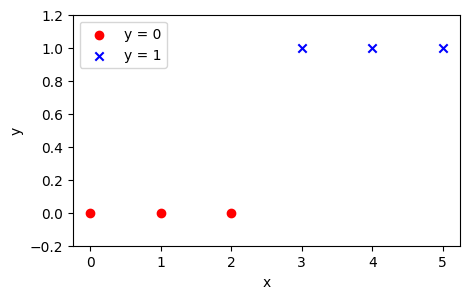

In [4]:
# 시각화
plt.figure(figsize=(5, 3))

for i in range(len(x_train)):
    if y_train[i] == 1:
        plt.scatter(x_train[i], y_train[i], color='blue', marker='x', label='y = 1' if i == 3 else "")
    else:
        plt.scatter(x_train[i], y_train[i], color='red', marker='o', label='y = 0' if i == 0 else "")

plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-0.2, 1.2)
plt.legend()
plt.show()

In [5]:
# 예측 함수
def prediction(x, w, b):
    z = w * x + b
    return sigmoid(z)

In [6]:
def squared_error_loss(fx, y):
    return 0.5 * (fx - y) ** 2

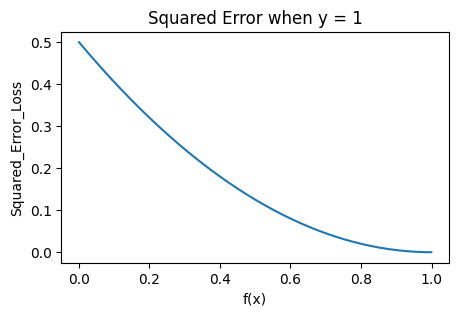

In [7]:
# y = 1일 때 squared error 모양 보기
f_values = np.linspace(0.001, 0.999, 200)
loss_y1_sq = 0.5 * (f_values - 1) ** 2

plt.figure(figsize=(5, 3))
plt.plot(f_values, loss_y1_sq)
plt.xlabel("f(x)")
plt.ylabel("Squared_Error_Loss")
plt.title("Squared Error when y = 1")
plt.show()

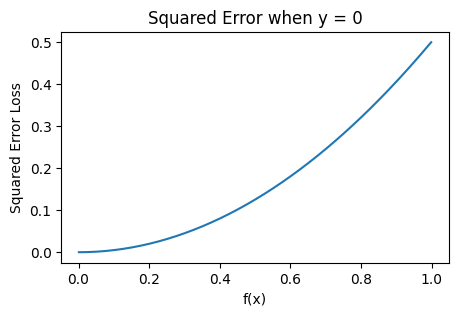

In [8]:
loss_y0_sq = 0.5 * (f_values - 0) ** 2

plt.figure(figsize=(5, 3))
plt.plot(f_values, loss_y0_sq)
plt.xlabel("f(x)")
plt.ylabel("Squared Error Loss")
plt.title("Squared Error when y = 0")
plt.show()

## Why squared error is a problem
## 왜 squared error가 문제가 되는가

Squared error looks reasonable for a single prediction.  
개별 예측 하나만 보면 squared error는 그럴듯해 보인다.  

But when it is combined with the sigmoid function, the overall cost surface is not smooth like linear regression.  
하지만 sigmoid 함수와 합쳐지면 전체 cost surface가 선형회귀처럼 매끄럽지 않다.  

This makes optimization harder.  
이 때문에 최적화가 더 어려워진다. 

In [9]:
def logistic_loss_y1(fx):
    return -np.log(fx)

def logistic_loss_y0(fx):
    return -np.log(1 - fx)

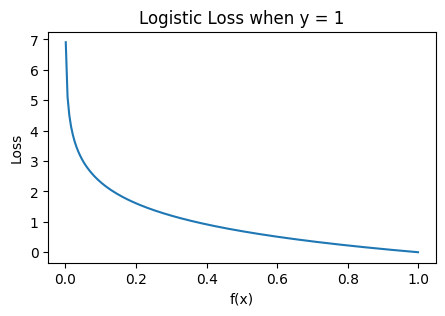

In [10]:
loss_y1_log = logistic_loss_y1(f_values)

plt.figure(figsize=(5, 3))
plt.plot(f_values, loss_y1_log)
plt.xlabel("f(x)")
plt.ylabel("Loss")
plt.title("Logistic Loss when y = 1")
plt.show()

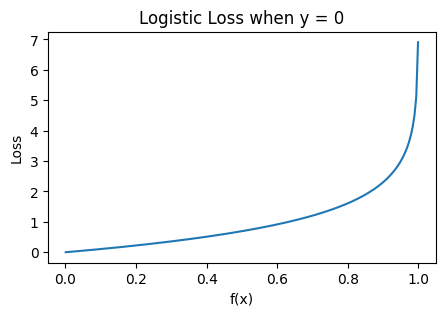

In [11]:
loss_y0_log = logistic_loss_y0(f_values)

plt.figure(figsize=(5, 3))
plt.plot(f_values, loss_y0_log)
plt.xlabel("f(x)")
plt.ylabel("Loss")
plt.title("Logistic Loss when y = 0")
plt.show()

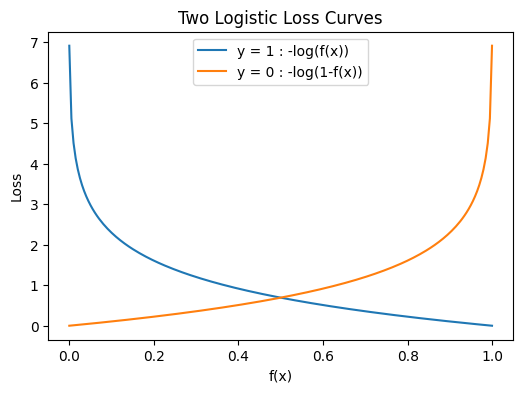

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(f_values, loss_y1_log, label="y = 1 : -log(f(x))")
plt.plot(f_values, loss_y0_log, label="y = 0 : -log(1-f(x))")
plt.xlabel("f(x)")
plt.ylabel("Loss")
plt.title("Two Logistic Loss Curves")
plt.legend()
plt.show()

In [13]:
def logistic_loss(fx, y):
    return -(y * np.log(fx) + (1 - y) * np.log(1 - fx))

In [14]:
test_values = [0.1, 0.5, 0.9]

print("=== y = 1 ===")
for fx in test_values:
    print(f"f(x)={fx:.1f}, loss={logistic_loss(fx, 1):.4f}")

print("\n=== y = 0 ===")
for fx in test_values:
    print(f"f(x)={fx:.1f}, loss={logistic_loss(fx, 0):.4f}")

=== y = 1 ===
f(x)=0.1, loss=2.3026
f(x)=0.5, loss=0.6931
f(x)=0.9, loss=0.1054

=== y = 0 ===
f(x)=0.1, loss=0.1054
f(x)=0.5, loss=0.6931
f(x)=0.9, loss=2.3026


In [15]:
def compute_cost(x, y, w, b):
    m = len(x)
    total_cost = 0
    
    for i in range(m):
        fx = prediction(x[i], w, b)
        total_cost += logistic_loss(fx, y[i])
    
    return total_cost / m

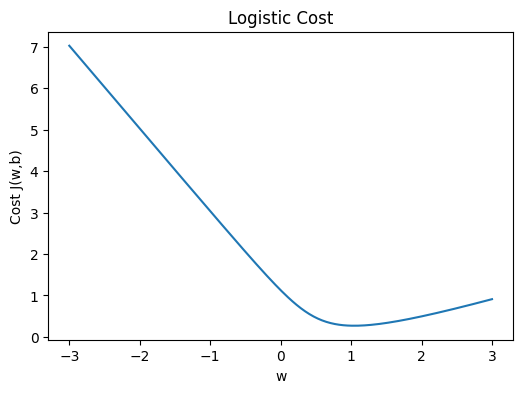

In [16]:
w_values = np.linspace(-3, 3, 200)
b = -2
cost_values = []

for w in w_values:
    cost_values.append(compute_cost(x_train, y_train, w, b))

plt.figure(figsize=(6, 4))
plt.plot(w_values, cost_values)
plt.xlabel("w")
plt.ylabel("Cost J(w,b)")
plt.title("Logistic Cost")
plt.show()

## Final Summary
## 최종 정리

Squared error works well for linear regression.  
Squared error는 선형회귀에는 잘 맞는다.

But logistic regression needs a loss that matches the sigmoid output.  
하지만 logistic regression은 sigmoid 출력에 맞는 loss가 필요하다.

For y=1, use -log(f(x)).  
y=1일 때는 -log(f(x))를 사용한다.

For y=0, use -log(1-f(x)).  
y=0일 때는 -log(1-f(x))를 사용한다.

This produces a cost function that is better suited to gradient descent.  
이렇게 하면 gradient descent에 더 적합한 cost function이 만들어진다.